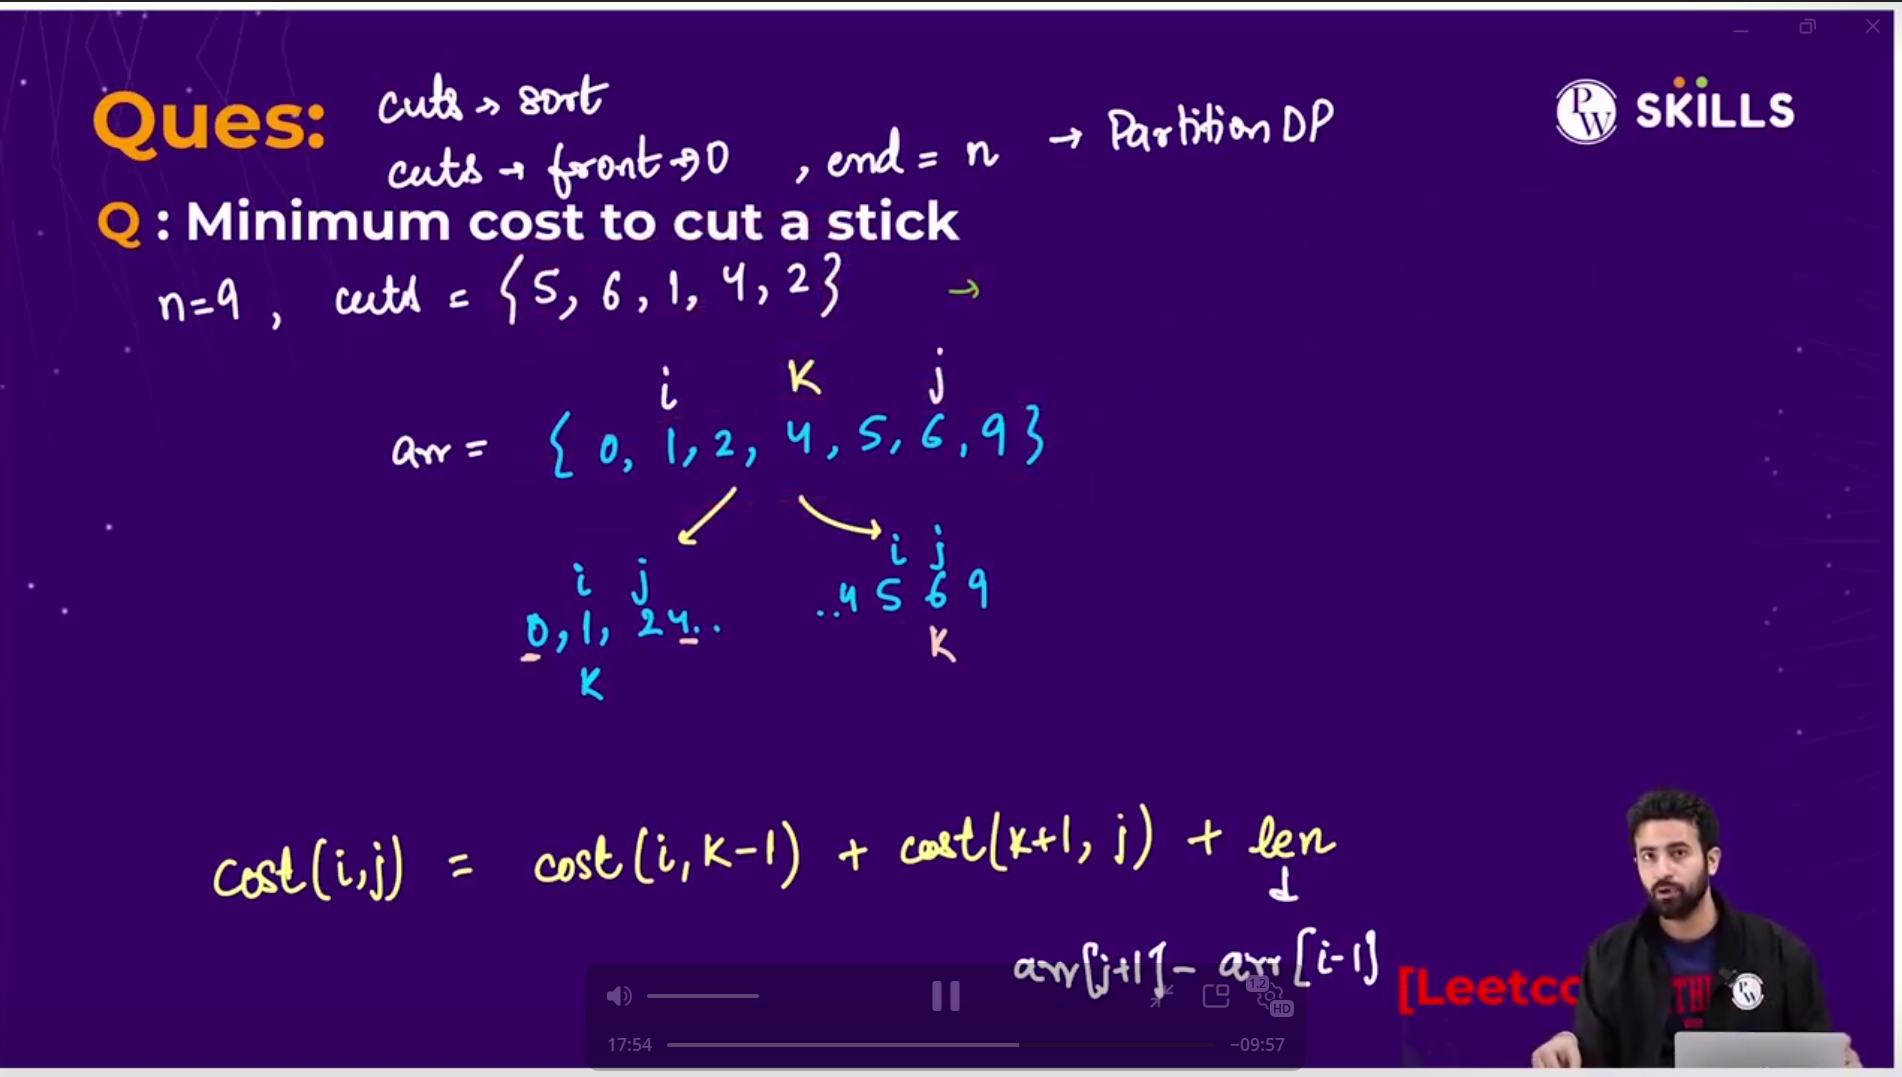

In [ ]:
# 1. Sort the array
# 2. Add the boundary front = 0 and end = n

In [5]:
from typing import List

class Solution:
    def minCost(self, n: int, cut: List[int]) -> int:

        # After adding boundary element array size become len(n) + 2
        arr = [0] * (len(cut) + 2)

        # Here we are mapping the element into new array with boundary element
        for i in range(len(cut)):
            arr[i + 1] = cut[i]
        
        print(arr)

        arr[0] = 0                      # Adding the front boundary
        arr[len(cut) + 1] = n           # Adding the end boundary
        arr.sort()                      # Sorting array

        return self.cost(1, len(arr) - 2, arr)

    def cost(self, i, j, arr):
        if i > j:
            return 0

        minn = float('inf')

        # So traversing starts from 1 idx as idx 0 is boundary element and 
        # goes upto n-2(again boundary element)
        for k in range(i, j + 1):
            lenn = arr[j + 1] - arr[i - 1]
            print(j+1)
            print(i-1)
            print("**")

            totalCost = (
                self.cost(i, k - 1, arr)
                + self.cost(k + 1, j, arr)
                + lenn
            )

            minn = min(minn, totalCost)

        return minn


# Driver Code
if __name__ == "__main__":
    n = 7
    cut = [1, 3, 4, 5]

    obj = Solution()

    result = obj.minCost(n, cut)

    print("Minimum Cost:", result)

[0, 1, 3, 4, 5, 0]
5
0
**
5
1
**
5
2
**
5
3
**
5
2
**
4
2
**
5
1
**
3
1
**
5
3
**
5
1
**
4
1
**
4
2
**
4
1
**
3
1
**
5
0
**
2
0
**
5
2
**
5
3
**
5
2
**
4
2
**
5
0
**
3
0
**
3
1
**
3
0
**
2
0
**
5
3
**
5
0
**
4
0
**
4
1
**
4
2
**
4
1
**
3
1
**
4
0
**
2
0
**
4
2
**
4
0
**
3
0
**
3
1
**
3
0
**
2
0
**
Minimum Cost: 16


# `Memo`

In [4]:
class Solution:
    def minCost(self, n: int, cut: List[int]) -> int:
        arr = [0] * (len(cut) + 2)

        for i in range(len(cut)):
            arr[i + 1] = cut[i]

        arr[0] = 0
        arr[len(cut) + 1] = n
        arr.sort()     # lenn = m

        m = len(arr)
        # i = 1 to m-2 and j = m-2 to 1

        dp = [[-1] * (m-1) for _ in range(m-1)]

        return self.cost(1, len(arr) - 2, arr,dp)

    def cost(self, i, j, arr,dp):
        if i > j:
            return 0

        if dp[i][j] != -1:
            return dp[i][j]
            
        minn = float('inf')

        for k in range(i, j + 1):
            lenn = arr[j + 1] - arr[i - 1]
            totalCost = (
                self.cost(i, k - 1, arr,dp)
                + self.cost(k + 1, j, arr,dp)
                + lenn
            )
            minn = min(minn, totalCost)

        dp[i][j] = minn
        return dp[i][j]

# `Striver Recursive Solution`

In [ ]:
def FindMinCost(i,j,cuts):
    # Base Case : No cuts to consider
    